In [1]:
!pip install matplotlib

In [3]:
!pip install seaborn

In [5]:
!pip install scikit-learn

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [73]:
print(os.listdir())

['.anaconda', '.conda', '.condarc', '.continuum', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.mgltools', '.ms-ad', '.pymol', '.pymoltimestamp', '.spyder-py3', '.vscode', '2uv0.cif', '3pjc.cif', 'anaconda3', 'AppData', 'Application Data', 'AQI Kol', 'AQI Prediction Renew.ipynb', 'AQI Prediction.ipynb', 'aqi_prediction_model.pkl', 'CAR-T cell 2.webp', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'Favorites', 'IntelGraphicsProfiles', 'Jedi', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{b887e316-ff4f-11ef-ae40-ba3d4ea4f668}.TM.blf', 'NTUSER.DAT{b887e316-ff4f-11ef-ae40-ba3d4ea4f668}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{b887e316-ff4f-11ef-ae40-ba3d4ea4f668}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'Structure-of-CAR-T.png', 'Templates', 'Untitled.ipynb', 

In [75]:
print(os.getcwd())

C:\Users\joyee


In [77]:
data=pd.concat([pd.read_csv(file)
                for file in glob.glob("AQI Kol/*.csv")], ignore_index=True)
print(data.head())

  Station ID        State     City                 Station Name  \
0  site_5238  West Bengal  Kolkata  Ballygunge, Kolkata - WBPCB   
1  site_5238  West Bengal  Kolkata  Ballygunge, Kolkata - WBPCB   
2  site_5238  West Bengal  Kolkata  Ballygunge, Kolkata - WBPCB   
3  site_5238  West Bengal  Kolkata  Ballygunge, Kolkata - WBPCB   
4  site_5238  West Bengal  Kolkata  Ballygunge, Kolkata - WBPCB   

                         Timestamp  PM2.5 (µg/m³)  PM10 (µg/m³)  NO (µg/m³)  \
0  2024-01-01T00:00:00.000000+0000          106.7         202.9        11.2   
1  2024-01-01T00:15:00.000000+0000          106.7         202.9         8.7   
2  2024-01-01T00:30:00.000000+0000          121.3         202.8         8.1   
3  2024-01-01T00:45:00.000000+0000          121.3         202.8         7.9   
4  2024-01-01T01:00:00.000000+0000          121.3         202.8         7.7   

   NO2 (µg/m³)  NOx (ppb)  ...  MP-Xylene (µg/m³)  AT (°C)  RH (%)  WS (m/s)  \
0         60.3       40.5  ...            

In [78]:
print(data.columns)

Index(['Station ID', 'State', 'City', 'Station Name', 'Timestamp',
       'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO (µg/m³)', 'NO2 (µg/m³)',
       'NOx (ppb)', 'NH3 (µg/m³)', 'SO2 (µg/m³)', 'CO (mg/m³)',
       'Ozone (µg/m³)', 'Benzene (µg/m³)', 'Toluene (µg/m³)', 'Xylene (µg/m³)',
       'O Xylene (µg/m³)', 'Eth-Benzene (µg/m³)', 'MP-Xylene (µg/m³)',
       'AT (°C)', 'RH (%)', 'WS (m/s)', 'WD (deg)', 'RF (mm)', 'TOT-RF (mm)',
       'SR (W/mt2)', 'BP (mmHg)', 'VWS (m/s)'],
      dtype='object')


In [81]:
print(data.info)

<bound method DataFrame.info of        Station ID        State     City                 Station Name  \
0       site_5238  West Bengal  Kolkata  Ballygunge, Kolkata - WBPCB   
1       site_5238  West Bengal  Kolkata  Ballygunge, Kolkata - WBPCB   
2       site_5238  West Bengal  Kolkata  Ballygunge, Kolkata - WBPCB   
3       site_5238  West Bengal  Kolkata  Ballygunge, Kolkata - WBPCB   
4       site_5238  West Bengal  Kolkata  Ballygunge, Kolkata - WBPCB   
...           ...          ...      ...                          ...   
561411   site_309  West Bengal  Kolkata    Victoria, Kolkata - WBPCB   
561412   site_309  West Bengal  Kolkata    Victoria, Kolkata - WBPCB   
561413   site_309  West Bengal  Kolkata    Victoria, Kolkata - WBPCB   
561414   site_309  West Bengal  Kolkata    Victoria, Kolkata - WBPCB   
561415   site_309  West Bengal  Kolkata    Victoria, Kolkata - WBPCB   

                              Timestamp  PM2.5 (µg/m³)  PM10 (µg/m³)  \
0       2024-01-01T00:00:00.000

In [85]:
print(data['Station Name'].unique())

['Ballygunge, Kolkata - WBPCB' nan 'Bidhannagar, Kolkata - WBPCB'
 'Fort William, Kolkata - WBPCB' 'Jadavpur, Kolkata - WBPCB'
 'Rabindra Bharati University, Kolkata - WBPCB'
 'Rabindra Sarobar, Kolkata - WBPCB' 'Victoria, Kolkata - WBPCB']


In [87]:
print(data.columns)

Index(['Station ID', 'State', 'City', 'Station Name', 'Timestamp',
       'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO (µg/m³)', 'NO2 (µg/m³)',
       'NOx (ppb)', 'NH3 (µg/m³)', 'SO2 (µg/m³)', 'CO (mg/m³)',
       'Ozone (µg/m³)', 'Benzene (µg/m³)', 'Toluene (µg/m³)', 'Xylene (µg/m³)',
       'O Xylene (µg/m³)', 'Eth-Benzene (µg/m³)', 'MP-Xylene (µg/m³)',
       'AT (°C)', 'RH (%)', 'WS (m/s)', 'WD (deg)', 'RF (mm)', 'TOT-RF (mm)',
       'SR (W/mt2)', 'BP (mmHg)', 'VWS (m/s)'],
      dtype='object')


In [89]:
data.columns=data.columns.str.lower()

In [91]:
print(data.columns)

Index(['station id', 'state', 'city', 'station name', 'timestamp',
       'pm2.5 (µg/m³)', 'pm10 (µg/m³)', 'no (µg/m³)', 'no2 (µg/m³)',
       'nox (ppb)', 'nh3 (µg/m³)', 'so2 (µg/m³)', 'co (mg/m³)',
       'ozone (µg/m³)', 'benzene (µg/m³)', 'toluene (µg/m³)', 'xylene (µg/m³)',
       'o xylene (µg/m³)', 'eth-benzene (µg/m³)', 'mp-xylene (µg/m³)',
       'at (°c)', 'rh (%)', 'ws (m/s)', 'wd (deg)', 'rf (mm)', 'tot-rf (mm)',
       'sr (w/mt2)', 'bp (mmhg)', 'vws (m/s)'],
      dtype='object')


In [93]:
data['station name']=(data['station name'].str.replace("Kolkata - WBPCB","",regex=False))

In [95]:
print(data['station name'].unique())

['Ballygunge, ' nan 'Bidhannagar, ' 'Fort William, ' 'Jadavpur, '
 'Rabindra Bharati University, ' 'Rabindra Sarobar, ' 'Victoria, ']


In [97]:
sample_data=(data.groupby('station name', group_keys=False).sample(n=100, random_state=42).reset_index(drop=True))

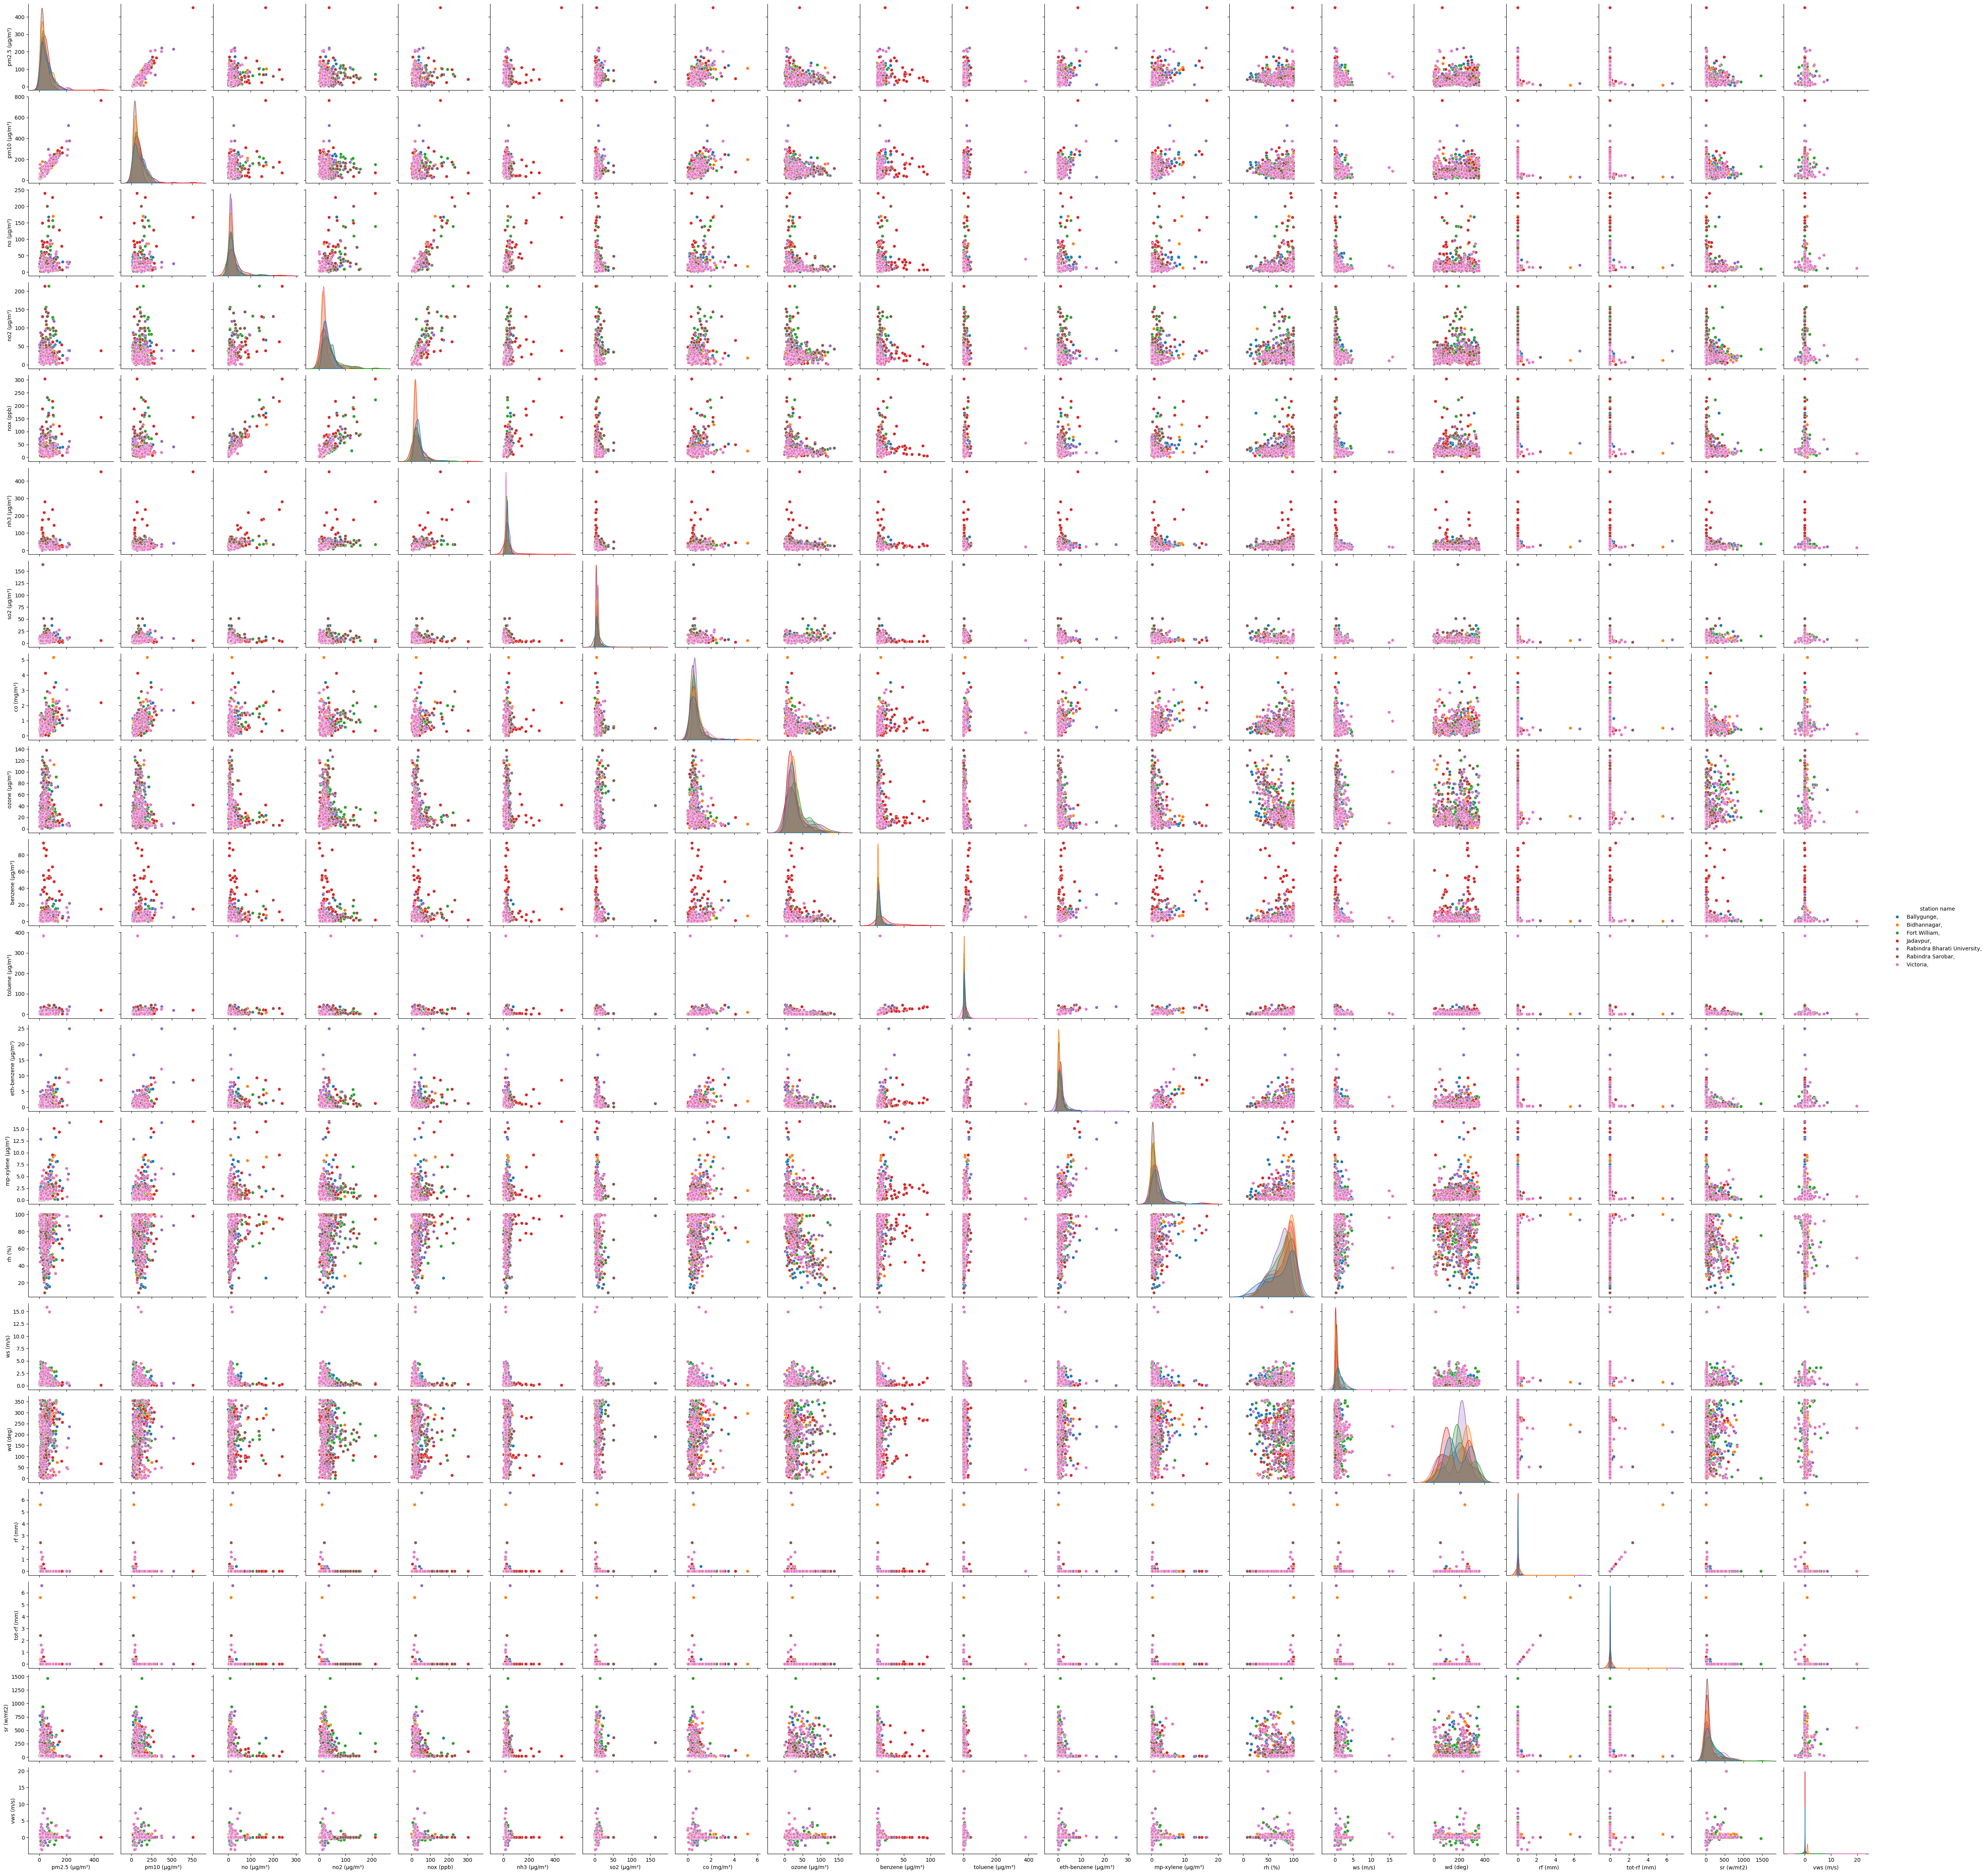

In [99]:
cols=['station name','pm2.5 (µg/m³)', 'pm10 (µg/m³)', 'no (µg/m³)', 'no2 (µg/m³)',
       'nox (ppb)', 'nh3 (µg/m³)', 'so2 (µg/m³)', 'co (mg/m³)',
       'ozone (µg/m³)', 'benzene (µg/m³)', 'toluene (µg/m³)', 'eth-benzene (µg/m³)', 'mp-xylene (µg/m³)',
        'rh (%)', 'ws (m/s)', 'wd (deg)', 'rf (mm)', 'tot-rf (mm)',
       'sr (w/mt2)',  'vws (m/s)']
sns.pairplot(sample_data[cols], hue='station name')
plt.show()

In [100]:
numeric_cols=sample_data.select_dtypes(include='number')
corr_matrix=numeric_cols.corr()

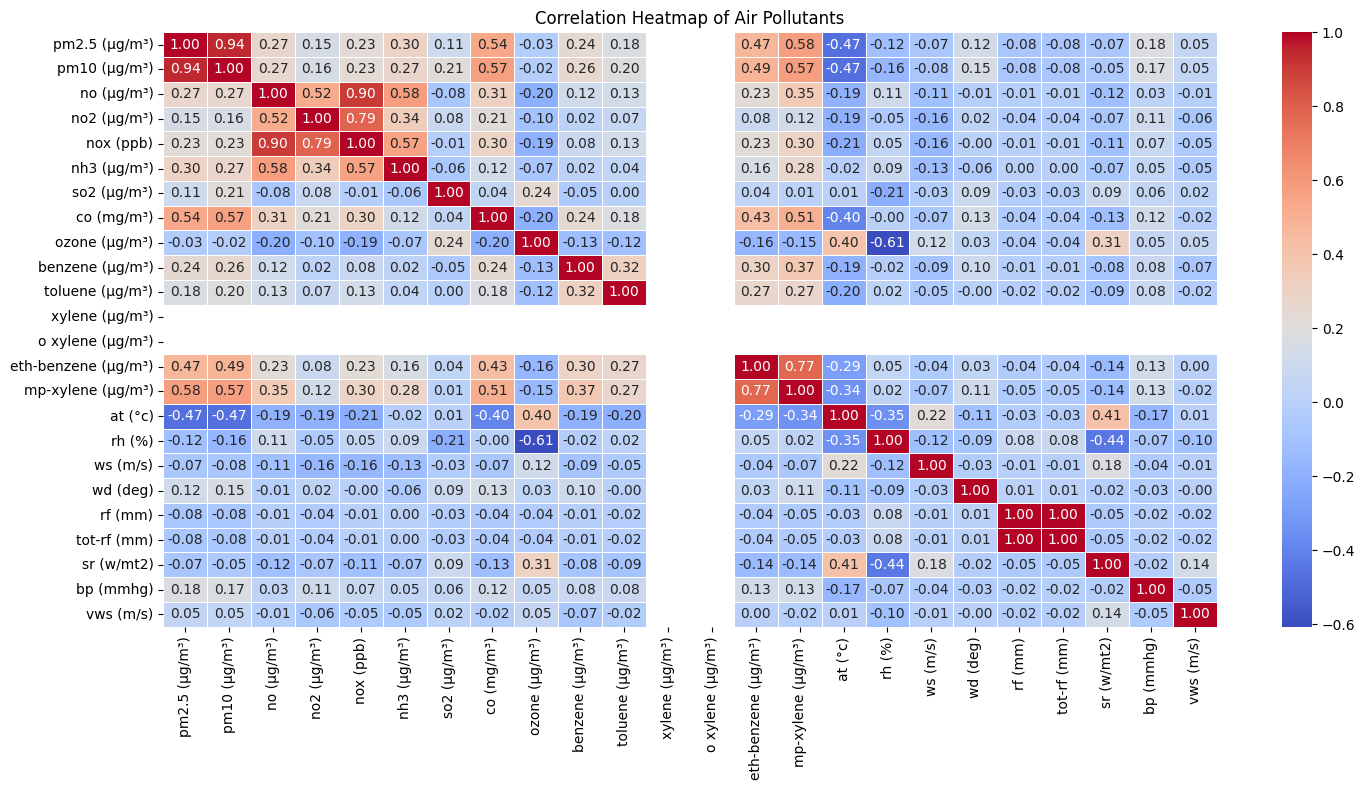

In [101]:
plt.figure(figsize=(15,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Air Pollutants")
plt.tight_layout()
plt.show()

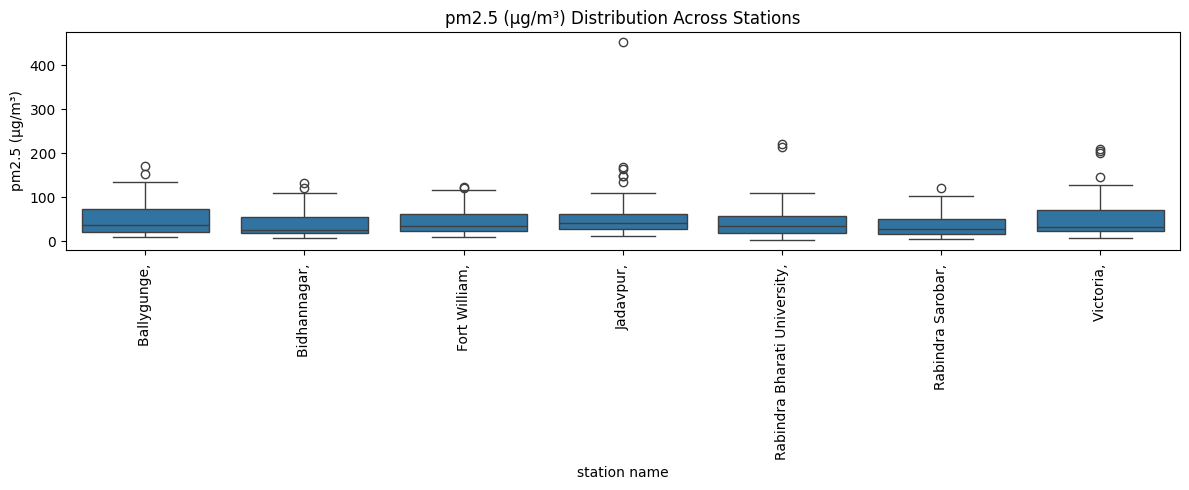

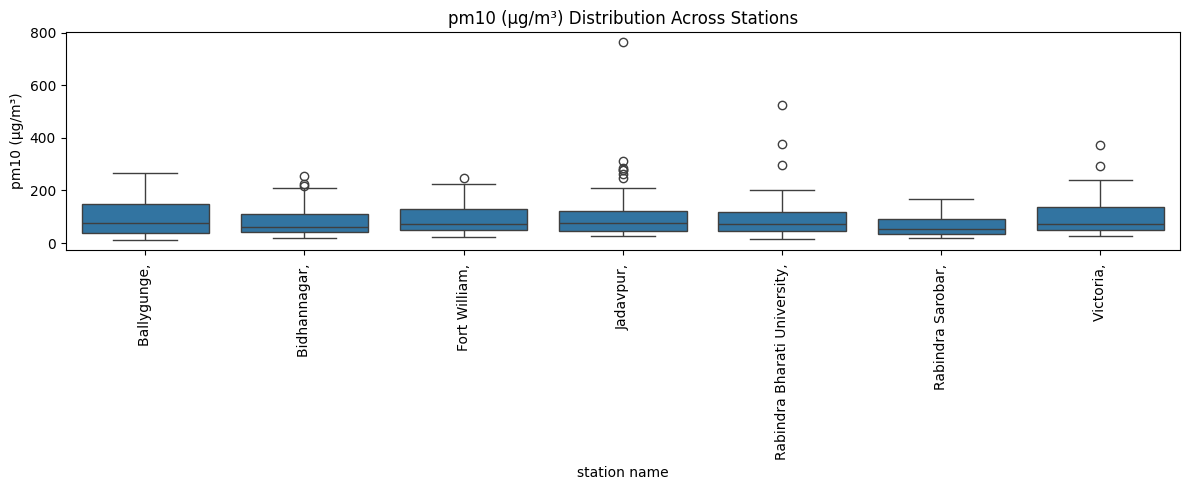

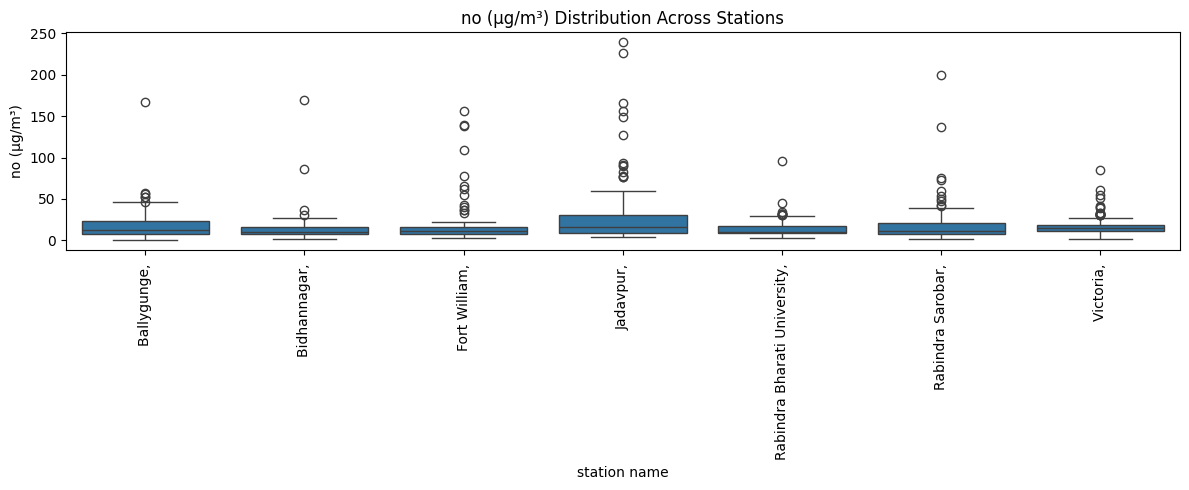

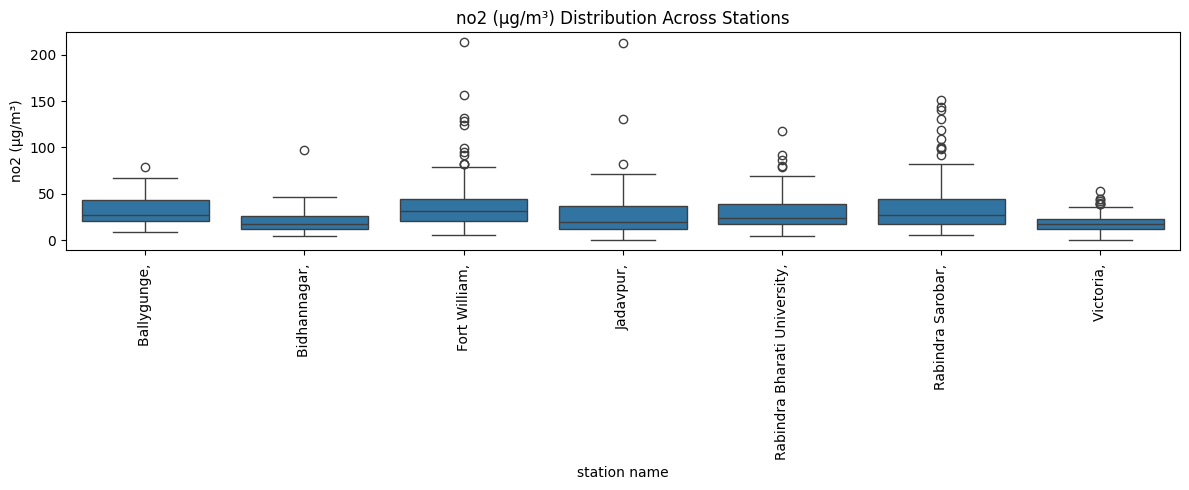

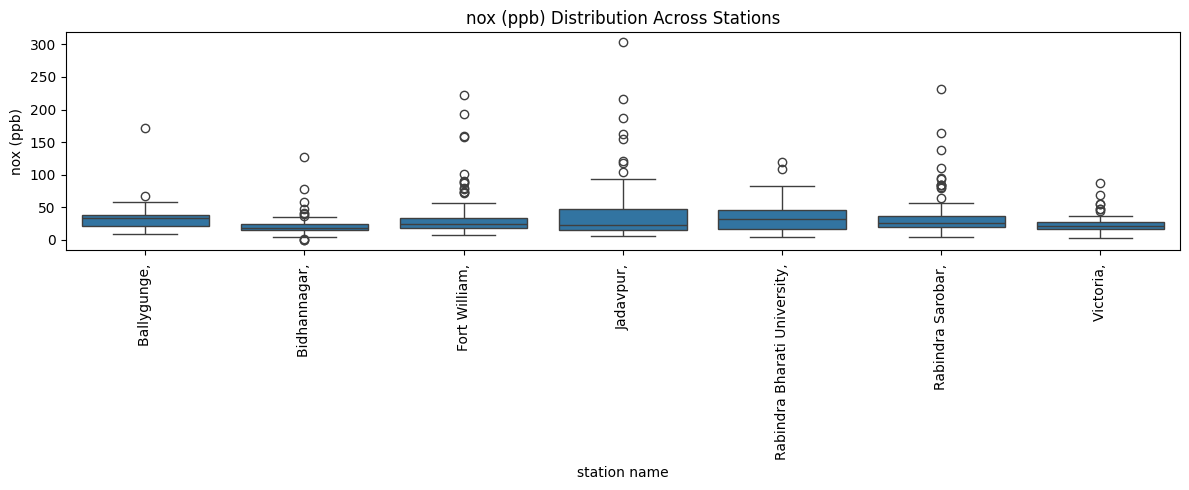

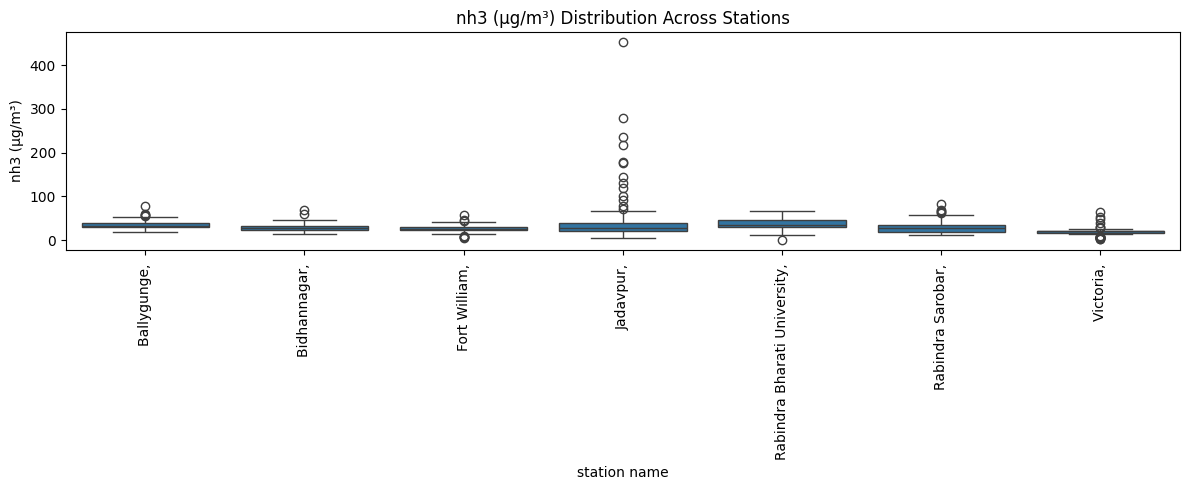

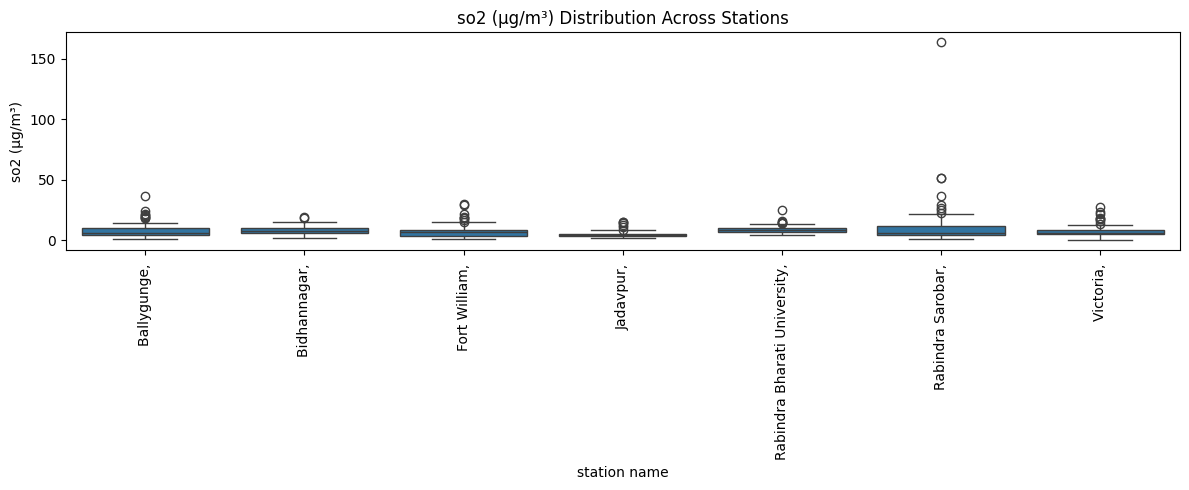

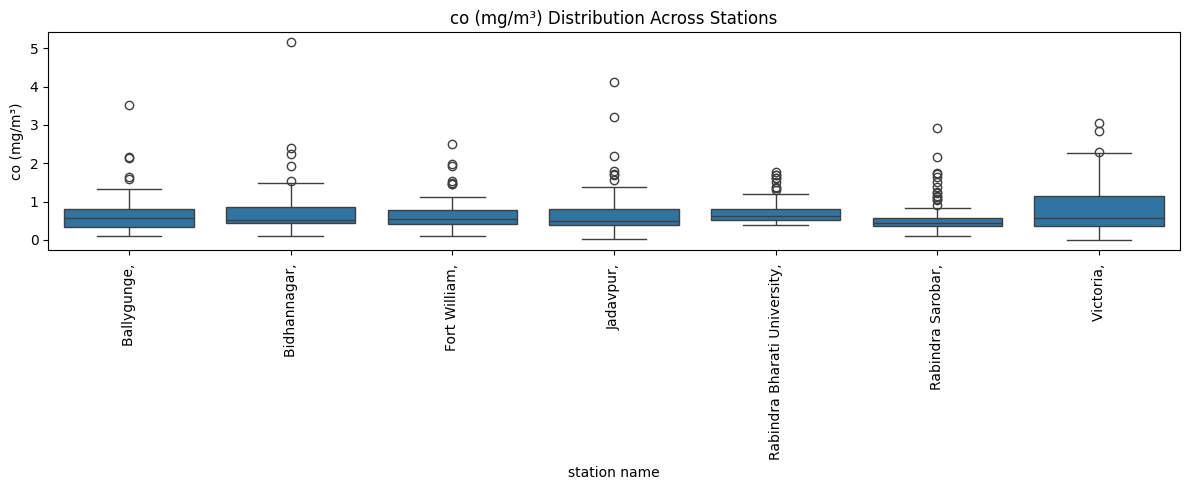

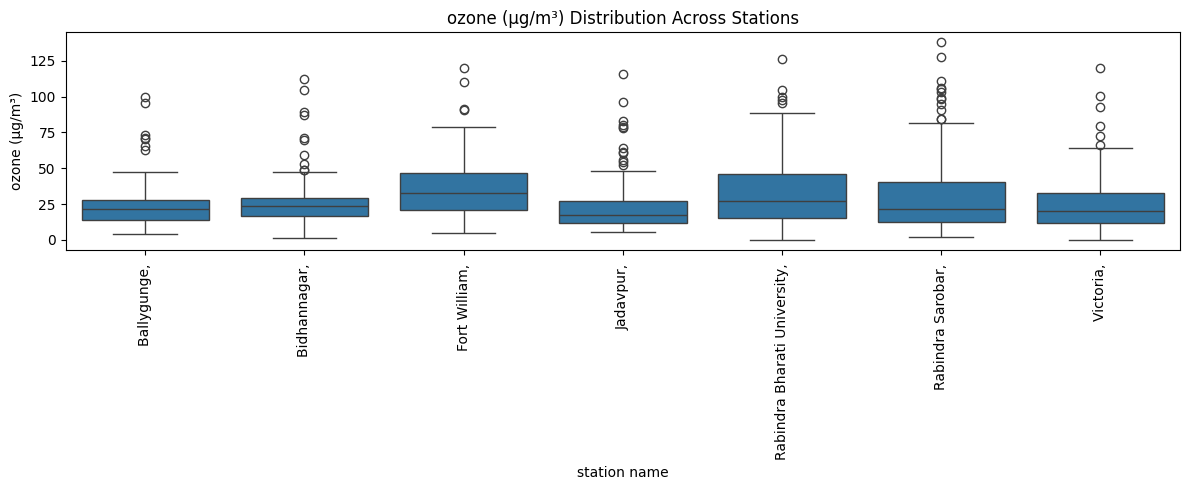

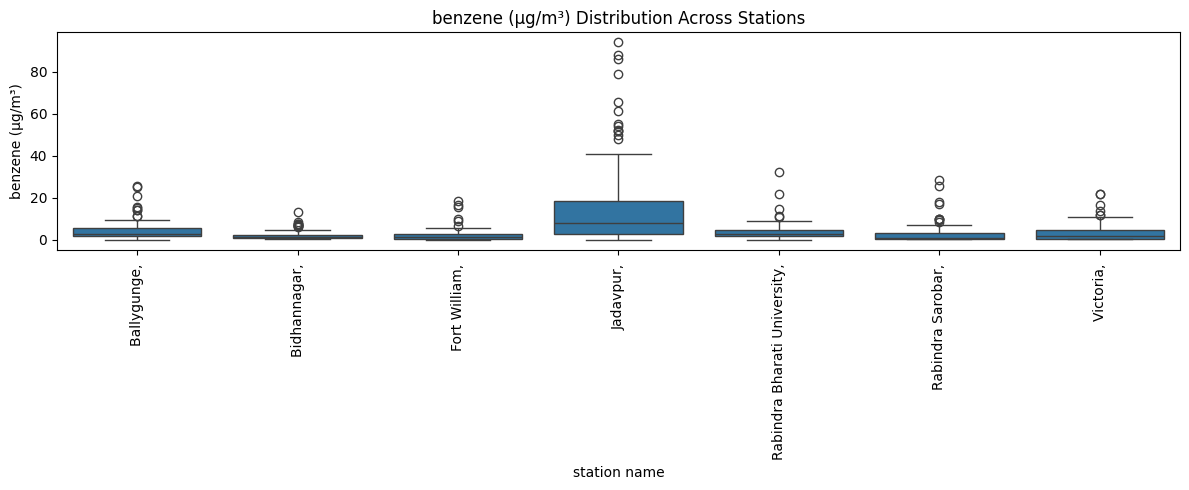

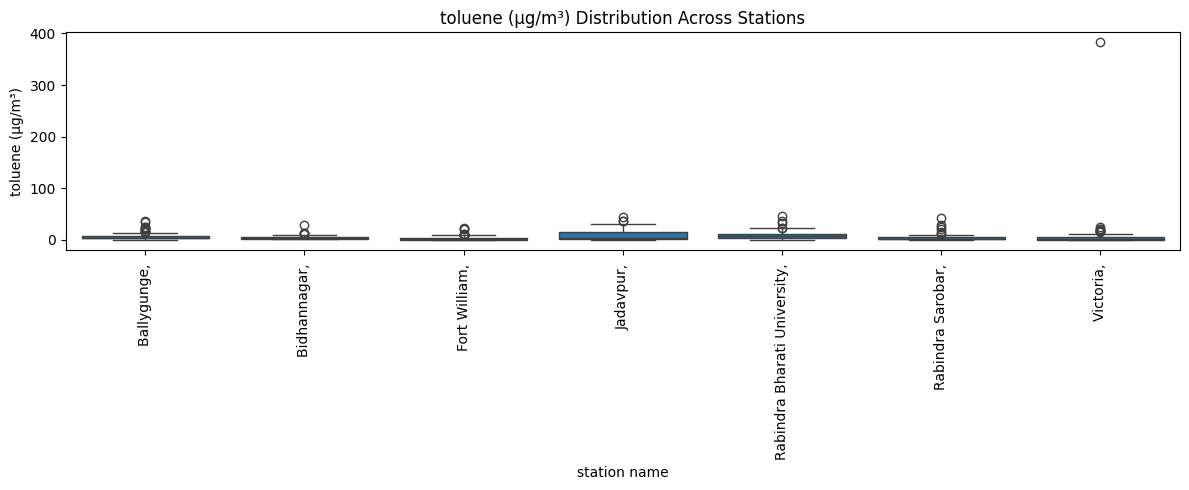

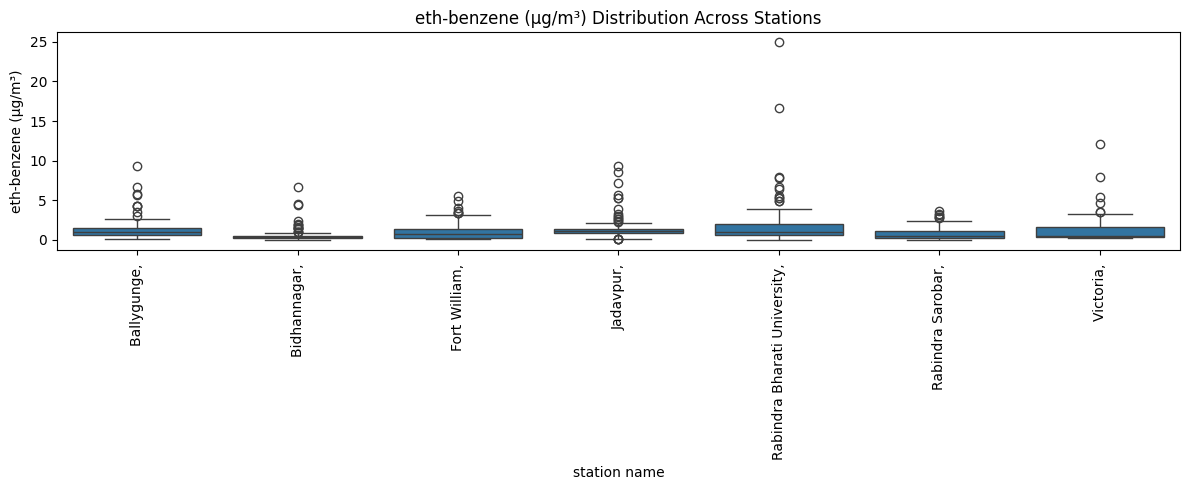

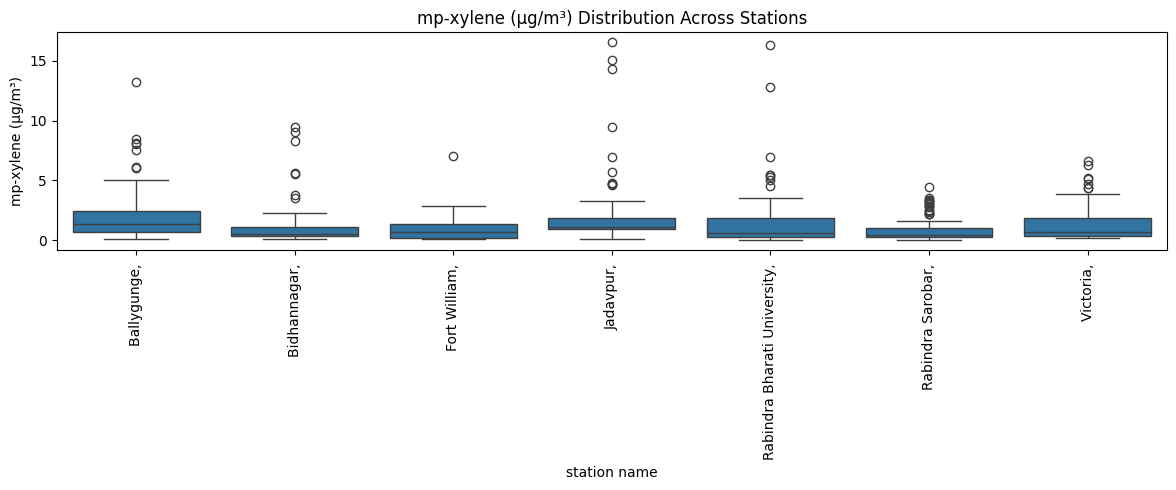

In [102]:
pollutants=['pm2.5 (µg/m³)', 'pm10 (µg/m³)', 'no (µg/m³)', 'no2 (µg/m³)',
       'nox (ppb)', 'nh3 (µg/m³)', 'so2 (µg/m³)', 'co (mg/m³)',
       'ozone (µg/m³)', 'benzene (µg/m³)', 'toluene (µg/m³)', 'eth-benzene (µg/m³)', 'mp-xylene (µg/m³)']
for col in pollutants:
    plt.figure(figsize=(12,5))
    sns.boxplot(x='station name', y=col, data=sample_data)
    plt.xticks(rotation=90)
    plt.title(f"{col} Distribution Across Stations")
    plt.tight_layout()
    plt.show()

In [107]:
breakpoints={
    "pm2.5":[(0,30,0,50),(31,60,51,100),
             (61,90,101,200),(91,120,201,300),
             (121,250,301,400),(251,500,401,500)],
    "pm10":[(0,50,0,50),(51,100,51,100),
            (101,250,101,200),(251,350,201,300),
            (351,430,301,400),(431,600,401,500)],
    "no2":[(0,40,0,50),(41,80,51,100),
           (81,180,101,200),(181,280,201,300),
           (281,400,301,400),(401,500,401,500)],
    "so2":[(0,40,0,50),(41,80,51,100),
           (81,380,101,200),(381,800,201,300),
           (801,1600,301,400),(1601,2000,401,500)],
    "co":[(0,1,0,50),(1,2,51,100),
          (2,10,101,200),(10,17,201,300),
          (17,34,301,400),(34,50,401,500)],
    "nh3":[(0,200,0,50),(201,400,51,100),
           (401,800,101,200),(801,1200,201,300),
           (1201,1800,301,400),(1801,2000,401,500)],
    "ozone":[(0,50,0,50),(51,100,51,100),
             (101,168,101,200),(169,208,201,300),
             (209,748,301,400),(749,1000,401,500)]
}

In [109]:
def calculate_subindex(concentration, pollutant):
    ranges=breakpoints[pollutant]
    for bplo, bphi, aqilo, aqihi in ranges:
        if bplo<=concentration<=bphi:
            return ((aqihi-aqilo)/(bphi-bplo))*(concentration-bplo)+aqilo
    return None

In [111]:
data['pm2.5_aqi']=data['pm2.5 (µg/m³)'].apply(lambda x:calculate_subindex(x,'pm2.5')) 
data['pm10_aqi']=data['pm10 (µg/m³)'].apply(lambda x:calculate_subindex(x,'pm10')) 
data['no2_aqi']=data['no2 (µg/m³)'].apply(lambda x:calculate_subindex(x,'no2')) 
data['so2_aqi']=data['so2 (µg/m³)'].apply(lambda x:calculate_subindex(x,'so2')) 
data['co_aqi']=data['co (mg/m³)'].apply(lambda x:calculate_subindex(x,'co')) 
data['nh3_aqi']=data['nh3 (µg/m³)'].apply(lambda x:calculate_subindex(x,'nh3')) 
data['ozone_aqi']=data['ozone (µg/m³)'].apply(lambda x:calculate_subindex(x,'ozone')) 

In [112]:
data['AQI']=data[['pm2.5_aqi','pm10_aqi','no2_aqi','so2_aqi','co_aqi','nh3_aqi','ozone_aqi']].max(axis=1)

In [115]:
X=data[['pm2.5 (µg/m³)', 'pm10 (µg/m³)', 'no2 (µg/m³)', 'so2 (µg/m³)', 'co (mg/m³)','nh3 (µg/m³)', 'ozone (µg/m³)', 'at (°c)', 'rh (%)', 'ws (m/s)']]
y=data['AQI']

In [117]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd
import numpy as np

# Features
features = [
    'pm2.5 (µg/m³)',
    'pm10 (µg/m³)',
    'no2 (µg/m³)',
    'so2 (µg/m³)',
    'co (mg/m³)',
    'nh3 (µg/m³)',
    'ozone (µg/m³)'
]

# Create model dataframe
model_data = data[features + ['AQI']].copy()

# Convert all columns to numeric
for col in model_data.columns:
    model_data[col] = pd.to_numeric(model_data[col], errors='coerce')

# Replace inf values
model_data.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill missing values
model_data = model_data.fillna(model_data.median())

# Sample optimized rows
model_data = model_data.sample(50000, random_state=42)

# X and y
X = model_data[features]
y = model_data['AQI']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Model
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.9963898342091808
MAE: 0.8848581672042999


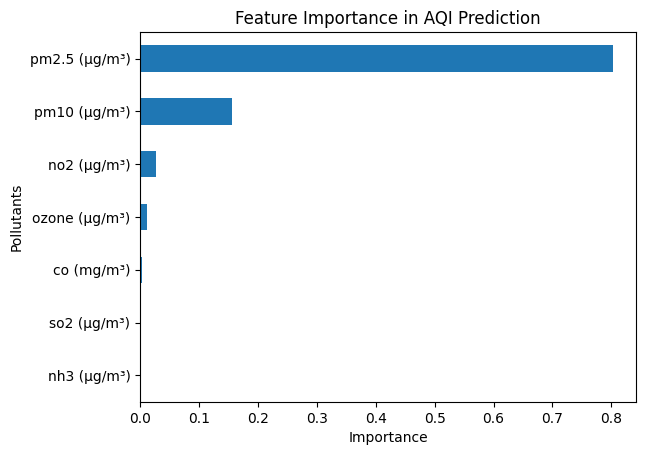

In [118]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=features)

importance.sort_values().plot(kind='barh')

plt.xlabel("Importance")
plt.ylabel("Pollutants")
plt.title("Feature Importance in AQI Prediction")

plt.show()

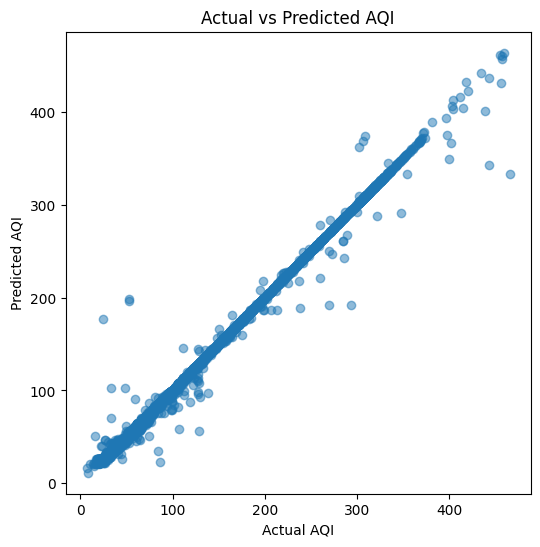

In [121]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")

plt.show()

In [123]:
import joblib

joblib.dump(model, "aqi_prediction_model.pkl")

['aqi_prediction_model.pkl']

In [125]:
def aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"



In [127]:
new_data = [[120, 210, 45, 12, 0.9, 40, 35]]

predicted_aqi = model.predict(new_data)

print("Predicted AQI:", predicted_aqi[0])

print("Predicted AQI:", predicted_value)
print("Category:", aqi_category(predicted_value))

Predicted AQI: 291.058055119516
Predicted AQI: 291.058055119516
Category: Poor


C:\Users\joyee\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [135]:
import os
notebook_path=os.path.abspath("AQI Prediction Renew.ipynb")
print(notebook_path)

C:\Users\joyee\AQI Prediction Renew.ipynb
